# Notebook 06 — Federated Learning with Flower and FedAvg

This notebook implements a privacy-preserving federated learning simulation
for network intrusion detection using four clients and the FedAvg algorithm.

In [5]:
# ============================================================
# VERIFY PYTHON, FLOWER, AND PYTORCH INSTALLATION
# ============================================================

import sys
import flwr as fl
import ray
import torch

print("Python version:", sys.version.split()[0])
print("Flower version:", fl.__version__)
print("Ray version:", ray.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python version: 3.13.14
Flower version: 1.35.0
Ray version: 2.58.0
PyTorch version: 2.13.0+cpu
CUDA available: False


In [6]:
# ============================================================
# LOAD PROCESSED TRAINING AND TEST DATA
# ============================================================

from pathlib import Path
import pandas as pd

# Update these paths only if your notebook is stored elsewhere.
TRAIN_PATH = Path("../data/processed/CICIDS2017_train.csv")
TEST_PATH = Path("../data/processed/CICIDS2017_test.csv")

# Confirm that both processed files exist.
assert TRAIN_PATH.exists(), f"Training file not found: {TRAIN_PATH.resolve()}"
assert TEST_PATH.exists(), f"Test file not found: {TEST_PATH.resolve()}"

# Load the processed datasets created in Notebook 03–05.
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nFirst five training columns:")
print(train_df.columns[:5].tolist())

print("\nLast five training columns:")
print(train_df.columns[-5:].tolist())

Training data shape: (2016638, 49)
Test data shape: (504160, 49)

First five training columns:
['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Length_of_Fwd_Packets', 'Fwd_Packet_Length_Max']

Last five training columns:
['Active_Max', 'Active_Min', 'Idle_Std', 'Original_Row_ID', 'Label']


In [8]:
# ============================================================
# SEPARATE FEATURES, ENCODE LABELS, AND STANDARDIZE FEATURES
# ============================================================

import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Find the target-label column.
label_candidates = [
    "Label",
    "label",
    "Class",
    "class",
    "Target",
    "target",
]

LABEL_COLUMN = next(
    (
        column
        for column in label_candidates
        if column in train_df.columns
    ),
    None,
)

assert LABEL_COLUMN is not None, (
    "Label column was not found. Check train_df.columns.tolist()."
)

# Confirm train and test files contain the same columns.
assert set(train_df.columns) == set(test_df.columns), (
    "Train and test datasets have different columns."
)

# Separate input features from the target label.
feature_columns = [
    column
    for column in train_df.columns
    if column != LABEL_COLUMN
]

# Encode target labels as integers: 0, 1, 2, ...
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(
    train_df[LABEL_COLUMN]
).astype(np.int64)

y_test = label_encoder.transform(
    test_df[LABEL_COLUMN]
).astype(np.int64)

# Convert features to numeric arrays.
X_train = train_df[feature_columns].to_numpy(
    dtype=np.float32
)

X_test = test_df[feature_columns].to_numpy(
    dtype=np.float32
)

# Standardize features using training-data statistics only.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(
    np.float32
)

X_test = scaler.transform(X_test).astype(
    np.float32
)

# Store model dimensions.
NUM_FEATURES = X_train.shape[1]
NUM_CLASSES = len(label_encoder.classes_)

print("✅ Step 5 complete: Features and labels are ready.")
print("Label column:", LABEL_COLUMN)
print("Number of input features:", NUM_FEATURES)
print("Number of classes:", NUM_CLASSES)
print("Class labels:", list(label_encoder.classes_))

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

✅ Step 5 complete: Features and labels are ready.
Label column: Label
Number of input features: 48
Number of classes: 15
Class labels: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']

X_train shape: (2016638, 48)
y_train shape: (2016638,)
X_test shape: (504160, 48)
y_test shape: (504160,)


In [9]:
# ============================================================
# SPLIT TRAINING DATA INTO FOUR SIMULATED ORGANIZATIONS
# Each client receives a separate, stratified partition.
# ============================================================

from sklearn.model_selection import StratifiedKFold

SEED = 42
NUM_CLIENTS = 4

client_partitions = []

splitter = StratifiedKFold(
    n_splits=NUM_CLIENTS,
    shuffle=True,
    random_state=SEED,
)

for client_id, (_, client_indices) in enumerate(
    splitter.split(X_train, y_train),
    start=1,
):
    X_client = X_train[client_indices]
    y_client = y_train[client_indices]

    client_partitions.append((X_client, y_client))

    print(
        f"Client {client_id}: "
        f"{len(X_client):,} records | "
        f"Class distribution: {np.bincount(y_client)}"
    )

Client 1: 504,160 records | Class distribution: [419012    390  25602   2057  34570   1045   1077   1186      2      7
  18139    644    294      5    130]
Client 2: 504,160 records | Class distribution: [419011    389  25603   2058  34569   1045   1077   1187      3      7
  18138    644    294      4    131]
Client 3: 504,159 records | Class distribution: [419011    389  25603   2057  34569   1046   1077   1186      2      7
  18139    644    294      4    131]
Client 4: 504,159 records | Class distribution: [419011    390  25603   2057  34569   1046   1077   1186      2      8
  18139    643    294      4    130]


In [10]:
# ============================================================
# FEDERATED TRAINING CONFIGURATION
# ============================================================

import random
import torch
from torch.utils.data import DataLoader, TensorDataset

RANDOM_SEED = 42
NUM_ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 256
LEARNING_RATE = 0.001

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# CPU is sufficient for this initial federated simulation.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training device:", DEVICE)
print("Federated rounds:", NUM_ROUNDS)
print("Local epochs per client:", LOCAL_EPOCHS)


def create_data_loader(X, y, shuffle=False):
    """
    Convert NumPy feature and label arrays into a PyTorch DataLoader.
    """
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )

# ============================================================
# CALCULATE CLASS WEIGHTS
# This prevents the model from ignoring minority attack classes.
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)

CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32,
).to(DEVICE)

print("Class weights:", CLASS_WEIGHTS.cpu().numpy())
print("Class imbalance handling is configured.")

Training device: cpu
Federated rounds: 10
Local epochs per client: 2
Class weights: [8.02141577e-02 8.62917404e+01 1.31277430e+00 1.63376522e+01
 9.72269654e-01 3.21479034e+01 3.12076454e+01 2.83335152e+01
 1.49380596e+04 4.63594922e+03 1.85297406e+00 5.22106934e+01
 1.14321884e+02 7.90838428e+03 2.57552734e+02]
Class imbalance handling is configured.


In [11]:
# ============================================================
# DEFINE THE NEURAL NETWORK MODEL
# Input  -> 128 neurons -> 64 neurons -> Output classes
# ============================================================

import torch.nn as nn


class NIDSNeuralNetwork(nn.Module):
    """
    Feed-forward neural network for intrusion detection classification.
    """

    def __init__(self, num_features, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)


# Create one temporary model to confirm the architecture.
model = NIDSNeuralNetwork(NUM_FEATURES, NUM_CLASSES).to(DEVICE)

print(model)

NIDSNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [12]:
# ============================================================
# LOCAL TRAINING AND EVALUATION FUNCTIONS
# These functions run independently on each federated client.
# ============================================================

def train_local_model(model, train_loader, epochs):
    """
    Train one local client model for the specified number of epochs.
    """
    model.train()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS,
    )

    for _ in range(epochs):
        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            predictions = model(features)
            loss = criterion(predictions, labels)

            loss.backward()
            optimizer.step()


def evaluate_model(model, data_loader):
    """
    Evaluate a model and return average loss and accuracy.
    """
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            predictions = model(features)
            loss = criterion(predictions, labels)

            total_loss += loss.item() * labels.size(0)

            predicted_classes = torch.argmax(predictions, dim=1)
            correct_predictions += (
                predicted_classes == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

print("Local training and evaluation functions are ready.")

Local training and evaluation functions are ready.


In [13]:
# ============================================================
# DEFINE A FLOWER CLIENT
# Each client trains only on its own local partition.
# ============================================================

import flwr as fl


class NIDSFlowerClient(fl.client.NumPyClient):
    """
    Flower client for federated network intrusion detection.
    """

    def __init__(self, X_client, y_client):
        self.model = NIDSNeuralNetwork(
            NUM_FEATURES,
            NUM_CLASSES,
        ).to(DEVICE)

        self.train_loader = create_data_loader(
            X_client,
            y_client,
            shuffle=True,
        )

    def get_parameters(self, config):
        """
        Send only model parameters to the server.
        Raw client data is never sent.
        """
        return [
            value.cpu().numpy()
            for value in self.model.state_dict().values()
        ]

    def set_parameters(self, parameters):
        """
        Receive updated global model parameters from the server.
        """
        model_state = self.model.state_dict()

        updated_state = {
            key: torch.tensor(value)
            for key, value in zip(model_state.keys(), parameters)
        }

        self.model.load_state_dict(updated_state, strict=True)

    def fit(self, parameters, config):
        """
        Train locally, then return updated model weights to the server.
        """
        self.set_parameters(parameters)

        train_local_model(
            self.model,
            self.train_loader,
            epochs=LOCAL_EPOCHS,
        )

        return (
            self.get_parameters(config={}),
            len(self.train_loader.dataset),
            {},
        )

    def evaluate(self, parameters, config):
        """
        Client-side evaluation is not used in this notebook.
        The server evaluates on the held-out CICIDS2017 test set.
        """
        self.set_parameters(parameters)

        return (
            0.0,
            len(self.train_loader.dataset),
            {},
        )


def client_fn(context):
    """
    Create one federated client using Flower's assigned partition ID.
    """

    client_id = int(context.node_config["partition-id"])

    X_client, y_client = client_partitions[client_id]

    return NIDSFlowerClient(
        X_client,
        y_client,
    ).to_client()

print("Flower federated client is ready.")
print(f"Configured simulated clients: {NUM_CLIENTS}")

Flower federated client is ready.
Configured simulated clients: 4


In [14]:
# ============================================================
# CONFIGURE FEDAVG
# The server aggregates client model updates using FedAvg.
# ============================================================

test_loader = create_data_loader(
    X_test,
    y_test,
    shuffle=False,
)

round_history = []
final_global_parameters = None


def evaluate_global_model(server_round, parameters, config):
    """
    Evaluate the aggregated global model on the central test set.
    """
    global final_global_parameters

    model = NIDSNeuralNetwork(
        NUM_FEATURES,
        NUM_CLASSES,
    ).to(DEVICE)

    model_state = model.state_dict()

    updated_state = {
        key: torch.tensor(value)
        for key, value in zip(model_state.keys(), parameters)
    }

    model.load_state_dict(updated_state, strict=True)

    loss, accuracy = evaluate_model(model, test_loader)

    # Save the latest global model parameters for final evaluation.
    final_global_parameters = [
        parameter.copy()
        for parameter in parameters
    ]

    round_history.append(
        {
            "Round": server_round,
            "Loss": loss,
            "Accuracy": accuracy,
        }
    )

    print(
        f"Round {server_round:02d} | "
        f"Test Loss: {loss:.4f} | "
        f"Test Accuracy: {accuracy:.4%}"
    )

    return loss, {"accuracy": accuracy}


strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=0.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_global_model,
)

print("FedAvg strategy is configured.")
print(f"Clients per round: {NUM_CLIENTS}")
print(f"Federated rounds to run: {NUM_ROUNDS}")

FedAvg strategy is configured.
Clients per round: 4
Federated rounds to run: 10


In [15]:
# ============================================================
# RESET RAY AFTER THE FAILED SIMULATION
# ============================================================

import ray

if ray.is_initialized():
    ray.shutdown()

print("✅ Ray reset complete. Ready to start the simulation again.")

✅ Ray reset complete. Ready to start the simulation again.


In [16]:
# ============================================================
# START FEDERATED LEARNING
# Four clients train locally for two epochs per global round.
# Their model updates are aggregated through FedAvg.
# ============================================================

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(
        num_rounds=NUM_ROUNDS,
    ),
    strategy=strategy,
    client_resources={
        "num_cpus": 1,
    },
)

results_df = pd.DataFrame(round_history)

print("\nFederated learning simulation completed.")
results_df

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-08-30 21:51:39,200	INFO worker.py:2024 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 4596368179.0, 'GPU': 1.0, 'memory': 10724859085.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'accelerator_type:GeForce-RTX-5050-Laptop-GPU': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO : 

Round 00 | Test Loss: 2.6983 | Test Accuracy: 3.4763%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.28902343069606645, {'accuracy': 0.8958326721675659}, 19.872941100009484)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Round 01 | Test Loss: 0.2890 | Test Accuracy: 89.5833%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.19512454846649843, {'accuracy': 0.9338642494446208}, 35.87254009998287)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (9, 0.1547223507317616, {'accuracy': 0.9593740082513488}, 147.6977052000002)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 10]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


Round 09 | Test Loss: 0.1547 | Test Accuracy: 95.9374%


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (10, 0.14906007478711758, {'accuracy': 0.9593184703268803}, 163.98092430000543)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 163.98s
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.698337818077351
INFO :      		round 1: 0.28902343069606645
INFO :      		round 2: 0.19512454846649843
INFO :      		round 3: 0.19210915583271862
INFO :      		round 4: 0.17365576580748487
INFO :      		round 5: 0.17897525706799286
INFO :      		round 6: 0.1525296062793818
INFO :      		round 7: 0.1944676285006061
INFO :      		round 8: 0.15560241403966735
INFO :      		round 9: 0.1547223507317616
INFO :      		round 10: 0.14906007478711758
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.03476277372262774),
INFO :      	              (1, 0.8958326721675659),
INFO :      	   

Round 10 | Test Loss: 0.1491 | Test Accuracy: 95.9318%

Federated learning simulation completed.


,Round,Loss,Accuracy
0,0,2.698338,0.034763
1,1,0.289023,0.895833
2,2,0.195125,0.933864
3,3,0.192109,0.938938
4,4,0.173656,0.946487
5,5,0.178975,0.943244
6,6,0.152530,0.956962
7,7,0.194468,0.947644
8,8,0.155602,0.959316
9,9,0.154722,0.959374


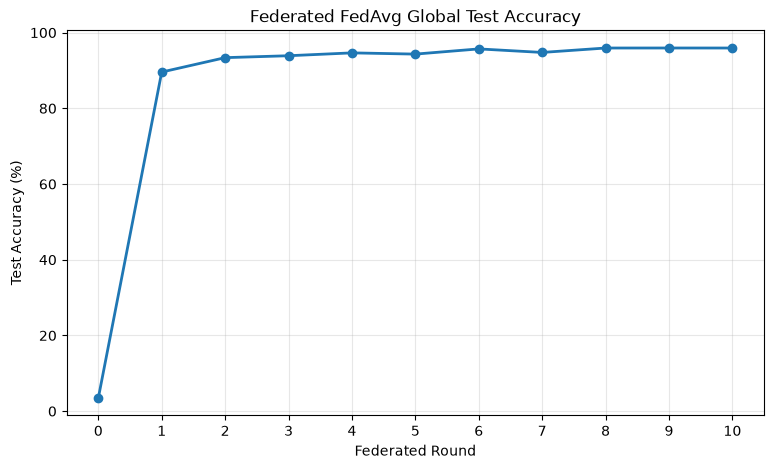

In [17]:
# ============================================================
# PLOT GLOBAL TEST ACCURACY ACROSS FEDERATED ROUNDS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    results_df["Round"],
    results_df["Accuracy"] * 100,
    marker="o",
    linewidth=2,
)

plt.title("Federated FedAvg Global Test Accuracy")
plt.xlabel("Federated Round")
plt.ylabel("Test Accuracy (%)")
plt.xticks(results_df["Round"])
plt.grid(alpha=0.3)

plt.show()

In [19]:
# ============================================================
# FINAL FEDERATED MODEL PREDICTIONS AND EVALUATION METRICS
# Run this cell only after the federated simulation in Step 12.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# Confirm that Step 12 completed in this active kernel.
assert (
    "final_global_parameters" in globals()
    and final_global_parameters is not None
), (
    "Final global model parameters are missing. "
    "Run Steps 5–12 first."
)

# Recreate the final global neural-network model.
final_model = NIDSNeuralNetwork(
    NUM_FEATURES,
    NUM_CLASSES,
).to(DEVICE)

final_model_state = final_model.state_dict()

updated_final_state = {
    key: torch.tensor(value)
    for key, value in zip(
        final_model_state.keys(),
        final_global_parameters,
    )
}

final_model.load_state_dict(
    updated_final_state,
    strict=True,
)

# Create the test-data loader.
test_loader = create_data_loader(
    X_test,
    y_test,
    shuffle=False,
)

# Generate predictions using the final federated global model.
final_model.eval()

all_predictions = []

with torch.no_grad():
    for features, _ in test_loader:
        features = features.to(DEVICE)

        outputs = final_model(features)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_predictions = np.array(all_predictions)

# Calculate overall weighted metrics.
federated_accuracy = accuracy_score(
    y_test,
    all_predictions,
)

federated_precision = precision_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

federated_recall = recall_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

federated_f1 = f1_score(
    y_test,
    all_predictions,
    average="weighted",
    zero_division=0,
)

# Calculate class-balanced metrics.
federated_macro_recall = recall_score(
    y_test,
    all_predictions,
    average="macro",
    zero_division=0,
)

federated_macro_f1 = f1_score(
    y_test,
    all_predictions,
    average="macro",
    zero_division=0,
)

federated_balanced_accuracy = balanced_accuracy_score(
    y_test,
    all_predictions,
)

print("✅ FINAL FEDERATED LEARNING RESULTS")
print("=" * 45)
print(f"Accuracy          : {federated_accuracy:.2%}")
print(f"Precision         : {federated_precision:.2%}")
print(f"Recall            : {federated_recall:.2%}")
print(f"F1 Score          : {federated_f1:.2%}")
print(f"Macro Recall      : {federated_macro_recall:.2%}")
print(f"Macro F1          : {federated_macro_f1:.2%}")
print(f"Balanced Accuracy : {federated_balanced_accuracy:.2%}")

✅ FINAL FEDERATED LEARNING RESULTS
Accuracy          : 95.93%
Precision         : 98.57%
Recall            : 95.93%
F1 Score          : 97.06%
Macro Recall      : 93.88%
Macro F1          : 56.84%
Balanced Accuracy : 93.88%


                            precision    recall  f1-score   support

                    BENIGN     0.9999    0.9516    0.9752    419012
                       Bot     0.0646    1.0000    0.1214       390
                      DDoS     0.9461    0.9999    0.9722     25603
             DoS GoldenEye     0.6601    1.0000    0.7953      2057
                  DoS Hulk     0.9435    0.9985    0.9702     34569
          DoS Slowhttptest     0.6807    0.9904    0.8069      1046
             DoS slowloris     0.5503    0.9805    0.7049      1077
               FTP-Patator     0.6701    0.9966    0.8014      1186
                Heartbleed     0.5000    1.0000    0.6667         2
              Infiltration     0.0210    1.0000    0.0411         7
                  PortScan     0.9609    0.9986    0.9794     18139
               SSH-Patator     0.2202    0.9938    0.3605       644
  Web Attack � Brute Force     0.1544    0.6871    0.2522       294
Web Attack � Sql Injection     0.0048    0.5000

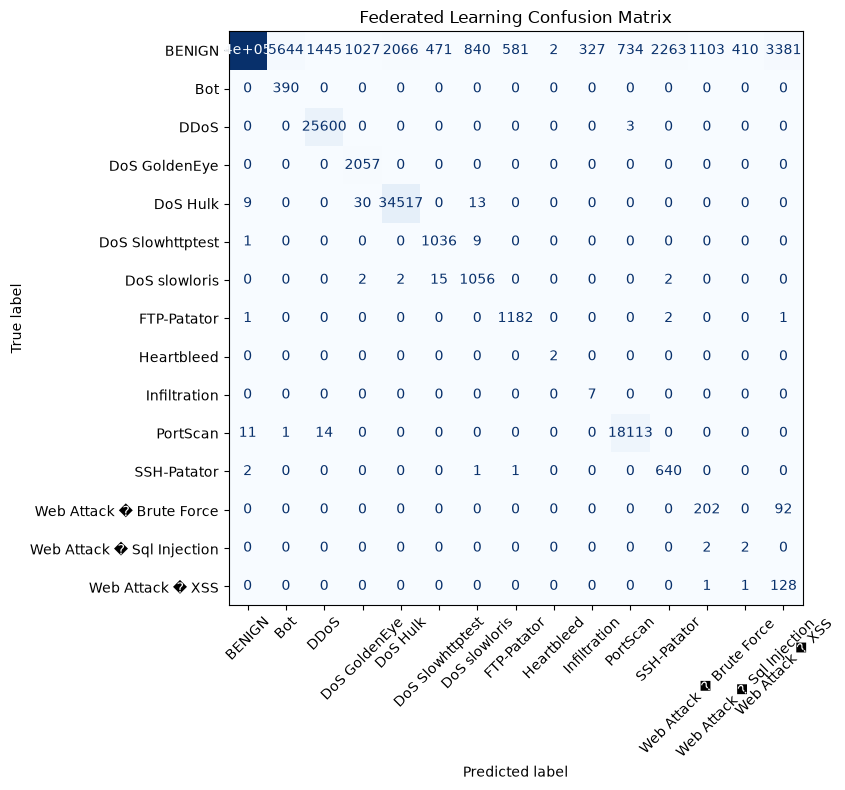

✅ Classification report and confusion matrix created.


In [21]:
# ============================================================
# CLASSIFICATION REPORT AND CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

# Convert original class labels into display text.
class_names = [
    str(label)
    for label in label_encoder.classes_
]

# Display precision, recall, and F1-score for every class.
print(
    classification_report(
        y_test,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

# Create and display the confusion matrix.
confusion_matrix_values = confusion_matrix(
    y_test,
    all_predictions,
)

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=class_names,
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
)

plt.title("Federated Learning Confusion Matrix")
plt.tight_layout()
plt.show()

print("✅ Classification report and confusion matrix created.")

In [23]:
# ============================================================
# SAVE FINAL FEDERATED LEARNING RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

federated_results = pd.DataFrame(
    {
        "Model": ["Federated Neural Network (FedAvg)"],
        "Training Approach": ["Federated Learning"],
        "Clients": [NUM_CLIENTS],
        "Rounds": [NUM_ROUNDS],
        "Local Epochs": [LOCAL_EPOCHS],
        "Accuracy": [federated_accuracy],
        "Precision": [federated_precision],
        "Recall": [federated_recall],
        "F1 Score": [federated_f1],
        "Macro Recall": [federated_macro_recall],
        "Macro F1": [federated_macro_f1],
        "Balanced Accuracy": [federated_balanced_accuracy],
    }
)

RESULTS_PATH = Path(
    "../results/federated_learning_results.csv"
)

RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

federated_results.to_csv(
    RESULTS_PATH,
    index=False,
)

print("✅ Federated results saved successfully.")
print("Saved to:", RESULTS_PATH.resolve())

federated_results

✅ Federated results saved successfully.
Saved to: C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\federated_learning_results.csv


,Model,Training Approach,Clients,Rounds,Local Epochs,Accuracy,Precision,Recall,F1 Score,Macro Recall,Macro F1,Balanced Accuracy
0,Federated Neural Network (FedAvg),Federated Learning,4,10,2,0.959318,0.985658,0.959318,0.970626,0.938771,0.568357,0.938771
